In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


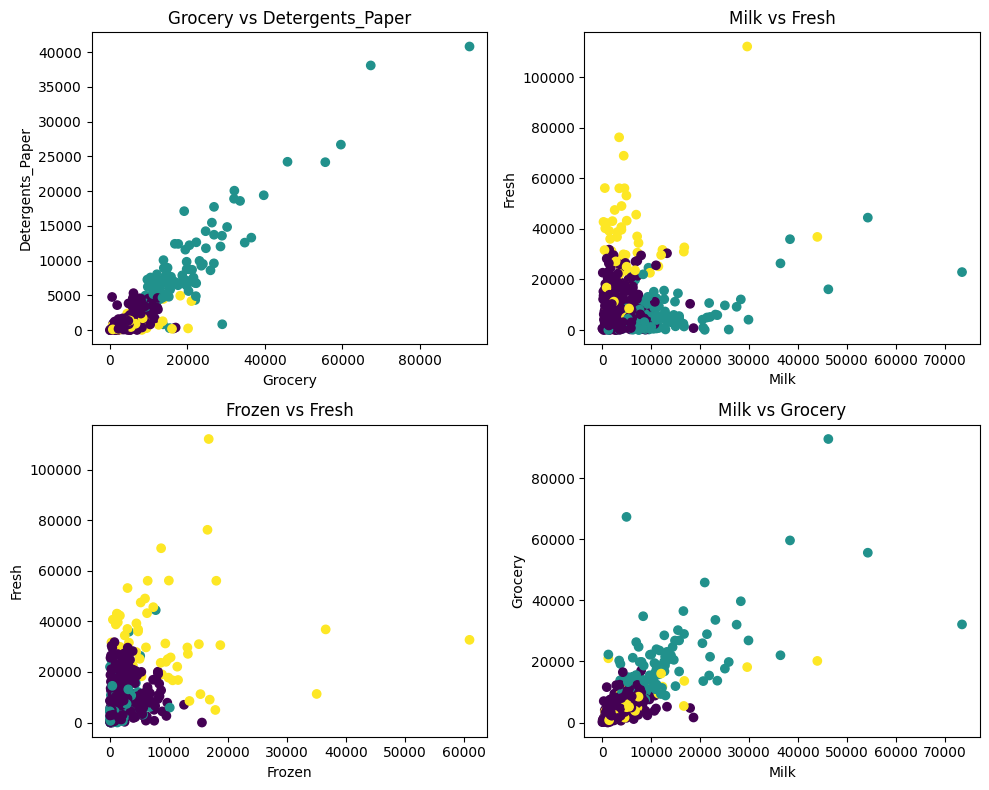

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Select features
X = df.drop(['Channel', 'Region'], axis=1)

# Scale
X_scaled = StandardScaler().fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


#plot
pairs = [
    ('Grocery', 'Detergents_Paper'),
    ('Milk', 'Fresh'),
    ('Frozen', 'Fresh'),
    ('Milk', 'Grocery')
]

plt.figure(figsize=(10, 8))

for i, (x, y) in enumerate(pairs):
    plt.subplot(2, 2, i+1) # grid: 2 rows, 2 columns
    plt.scatter(df[x], df[y], c=df['Cluster'])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

